In [1]:
%cd /content
!rm -rf mccain-internship
!git clone https://github.com/PushkargithubCSE/mccain-internship.git  
%cd mccain-internship/week-3/potato-finetuning
PROJECT_PATH = "/content/mccain-internship/week-3/potato-finetuning"

!pip install -q "rfdetr[train]" roboflow python-dotenv supervision huggingface_hub

/content
Cloning into 'mccain-internship'...
remote: Enumerating objects: 542, done.
remote: Counting objects: 100% (542/542), done.
remote: Compressing objects: 100% (397/397), done.
remote: Total 542 (delta 135), reused 489 (delta 88), pack-reused 0 (from 0)
Receiving objects: 100% (542/542), 23.47 MiB | 19.47 MiB/s, done.
Resolving deltas: 100% (135/135), done.
/content/mccain-internship/week-3/potato-finetuning
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.6/376.6 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 19.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 604.7/604.7 kB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 129.4 MB/s eta 0:00:0000:01
   ━━━━━

In [ ]:
import os
from dotenv import load_dotenv
from roboflow import Roboflow

load_dotenv(f"{PROJECT_PATH}/.env")
api_key = os.getenv("ROBOFLOW_API_KEY")
if not api_key:
    raise RuntimeError("ROBOFLOW_API_KEY is missing from the project .env file")
os.environ["ROBOFLOW_API_KEY"] = api_key

try:
    rf = Roboflow(api_key=api_key)
    print("Success: API key is valid!")
except Exception as e:
    print(f"Authentication Failed: {e}")

✅ Success: API key is valid!


In [ ]:
import os
from dotenv import load_dotenv
from roboflow import Roboflow

load_dotenv(f"{PROJECT_PATH}/.env")
api_key = os.getenv("ROBOFLOW_API_KEY")
if not api_key:
    raise RuntimeError("ROBOFLOW_API_KEY is missing from the project .env file")

rf = Roboflow(api_key=api_key)
project = rf.workspace("pushkar-chandra").project("object-detection-yntmm")
version = project.version(1)
dataset = version.download("coco")

print(f"Dataset ready at: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Object-Detection-1 in coco:: 100%|██████████| 21/21 [00:00<00:00, 4390.85it/s]

✓ Dataset ready at: /content/mccain-internship/week-3/potato-finetuning/Object-Detection-1


In [ ]:
import os
from dotenv import load_dotenv
from huggingface_hub import hf_hub_download, login

load_dotenv(f"{PROJECT_PATH}/.env")
hf_token = os.getenv("HUGGINGFACE_TOKEN")
if not hf_token:
    raise RuntimeError("HUGGINGFACE_TOKEN is missing from the project .env file")
login(token=hf_token)

REPO_ID = "pushkar0002/finetune"

checkpoint_path = hf_hub_download(
    repo_id=REPO_ID,
    filename="checkpoint_best_ema.pth"
)

print(f"Checkpoint downloaded to: {checkpoint_path}")

checkpoint_best_ema.pth: reconstructing file:   0%|          |  0.00B /  128MB            

checkpoint_best_ema.pth: downloading bytes:           |  0.00B            

✓ Checkpoint downloaded to: /root/.cache/huggingface/hub/models--pushkar0002--finetune/snapshots/a66ff4c804677bb2e7975ba308d434f1a06a3363/checkpoint_best_ema.pth


In [5]:
from rfdetr import RFDETRBase

model = RFDETRBase(pretrain_weights=checkpoint_path)
print("✓ Fine-tuned model loaded")

The `RFDETRBase` was deprecated since v1.7.0. It will be removed in v2.0.0.
[2026-08-27 10:04:32] [WARNING] rf-detr - Checkpoint has 2 classes but model is configured for 90. Using checkpoint class count (2). Pass num_classes=2 to suppress this warning.


✓ Fine-tuned model loaded


In [6]:
import json

test_path = f"{dataset.location}/test"

with open(f"{test_path}/_annotations.coco.json") as f:
    test_coco = json.load(f)

print(f"Test images: {len(test_coco['images'])}")
print(f"Test annotations: {len(test_coco['annotations'])}")

Test images: 2
Test annotations: 3


[2026-08-27 10:04:42] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. For full GPU throughput (e.g. ~8x on T4 via FP16 Tensor Cores), call model.inference(dtype=torch.float16).


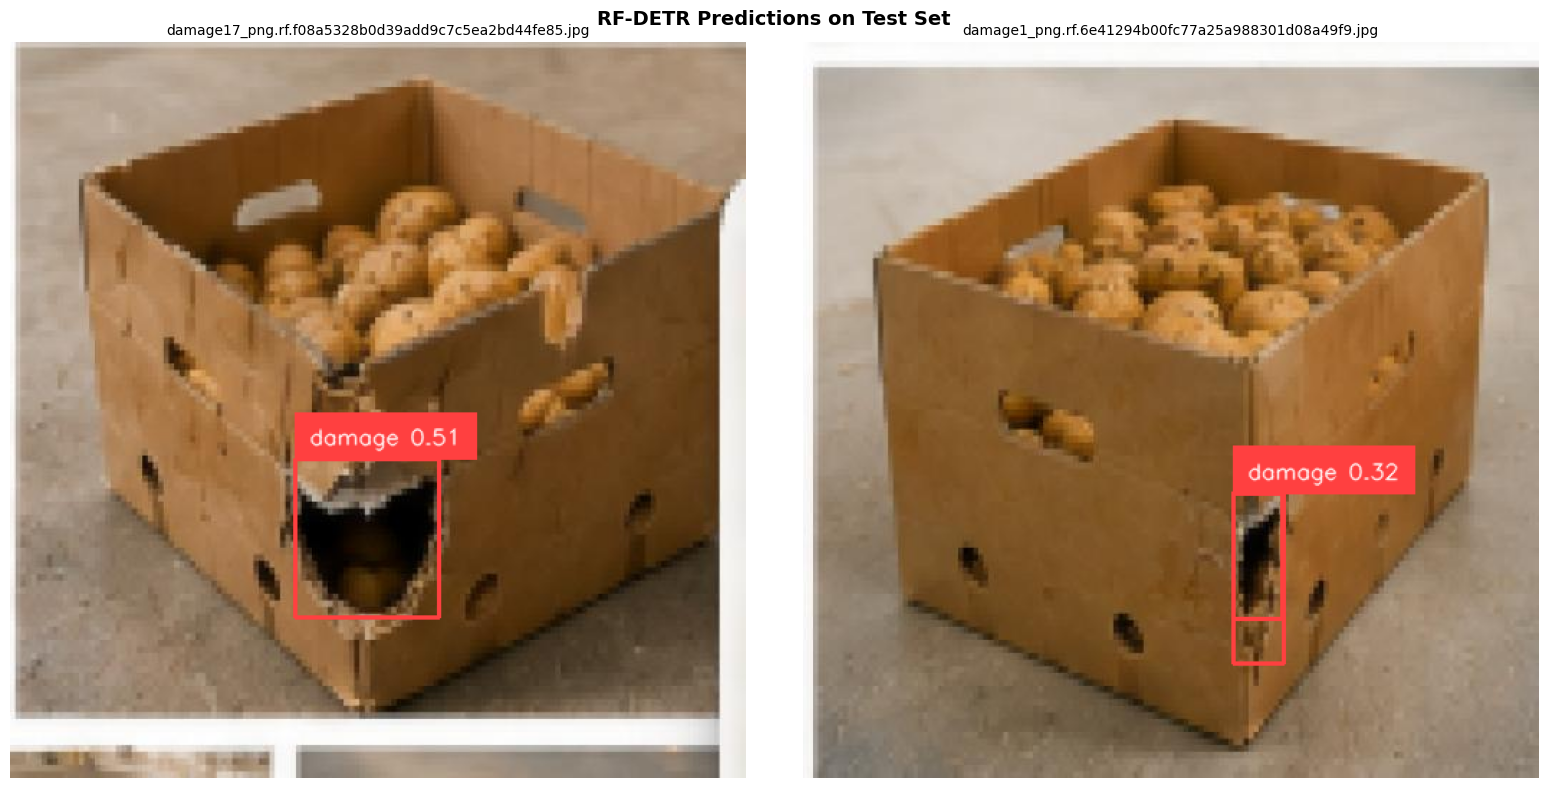

✓ Saved to data/test_predictions.png


In [7]:
import supervision as sv
from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(test_coco['images']), figsize=(8 * len(test_coco['images']), 8))
if len(test_coco['images']) == 1:
    axes = [axes]

for idx, img_info in enumerate(test_coco['images']):
    img_path = f"{test_path}/{img_info['file_name']}"
    img = Image.open(img_path)

    detections = model.predict(img_path, threshold=0.3)
    labels = [f"damage {conf:.2f}" for conf in detections.confidence]

    annotated = sv.BoxAnnotator().annotate(scene=img.copy(), detections=detections)
    annotated = sv.LabelAnnotator().annotate(scene=annotated, detections=detections, labels=labels)

    axes[idx].imshow(annotated)
    axes[idx].set_title(img_info['file_name'], fontsize=10)
    axes[idx].axis('off')

plt.suptitle('RF-DETR Predictions on Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PROJECT_PATH}/data/test_predictions.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Saved to data/test_predictions.png")